### Build spider plots with confidence intervals
### Julian Moran
### 2026-06-09

In [1]:
import logging
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from dotenv import load_dotenv
from matplotlib import colors
from matplotlib import cm
from pathlib import Path
from scipy.stats import norm

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

In [2]:
# ============================================================
#   Args
# ============================================================

FILE_PERFORMANCE_DATA = f"./___EAGLE-AI_performance_bound_withPhen.tsv"
THRESHOLD_CONFIDENCE = 0.95
OUT_DIR = f"./"

In [3]:
# ============================================================
#   In
# ============================================================

df_performance = pl.read_csv(
    FILE_PERFORMANCE_DATA,
    separator="\t",
    null_values=["NA", "CL"]
)

df_performance

publication,gene,curator_assigned_case_id,eagle-ai_assigned_case_id,case_in_eagle,case_id_match,curator_assigned_variant_id,eagle-ai_variant_id,variant_in_eagle,variant_enough_info,variant_id_match,phenotype_accuracy_rating,manual_score,eagle_ai_score,score_diff,score_diff_reason,score_diff_sub_reason,reason_explanation,eagle-ai_phenotype,curator_phenotype
str,str,str,str,str,bool,str,str,str,bool,bool,i64,f64,f64,f64,str,str,str,str,str
"""tassinari_2023""","""CDKL5""","""mouse_KO_wang_2012""",null,"""FN""",false,null,null,null,null,null,null,2.0,0.0,2.0,"""missed_case""","""missed_external_paper""","""The mouse model seen here is o…",null,null
"""tassinari_2023""","""CDKL5""","""mouse_KO_ren_2019""","""CDD_Mouse_Model_01""","""TP""",false,null,null,null,null,null,null,2.0,3.0,1.0,"""discretion""","""discretion""",null,"""Autistic features, impaired ne…",null
"""tassinari_2023""","""CDKL5""","""mouse_KO_amendola_2014""",null,"""TN""",false,null,null,null,null,null,null,0.0,0.0,0.0,null,null,null,null,null
"""khan_2024""","""CDKL5""","""PKASD-18""","""PKASD-18""","""TP""",true,"""NM_003159.3:c.2626A>G""","""NM_003159.3:c.2626A>G; p.Ile87…","""TP""",true,false,8,0.1,0.1,0.0,null,null,null,"""ASD, intellectual disability, …","""ASD diagnosed by pediatrician;…"
"""khan_2024""","""CDKL5""","""codina_sola_CDKL5_P1""",null,"""FN""",false,"""p.Pro647Leu""",null,"""FN""",false,false,null,0.1,0.0,0.1,"""missed_case""","""bad_table_parsing""",null,null,"""ASD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""becker_2020""","""CASK""","""becker_2020_2018ASD_twin_2""",null,"""TN""",null,null,null,null,null,null,null,0.0,0.0,0.0,null,null,null,null,"""ASD features"""
"""becker_2020""","""CASK""","""becker_2020_2018_ID_P1""",null,"""TN""",null,null,null,null,null,null,null,0.0,0.0,0.0,null,null,null,null,"""intellectual disability"""
"""seto_2017""","""CASK""","""seto_2017_P1""","""Patient 1""","""TP""",false,"""NM_003688.3:c.1424G>T""","""chrX:41437672C>A, NM_003688.3(…","""TP""",true,false,8,0.1,0.5,0.4,"""failed_logic; missed_phenotype…","""ignored_variant_details; ignor…",null,"""ASD, intellectual disability, …","""ASD features; poor verbal comm…"


In [4]:
# ============================================================
#   Wrangle
# ============================================================

df_cases = (
    df_performance.select([
        pl.col("case_in_eagle").str.contains(r"(^|,)TP($|,)").sum().alias("TP"),
        pl.col("case_in_eagle").str.contains(r"(^|,)FP($|,)").sum().alias("FP"),
        pl.col("case_in_eagle").str.contains(r"(^|,)FN($|,)").sum().alias("FN")
    ])
    .with_columns(pl.lit("Three-shot (agentic)").alias("Model"))
    .select(["Model", "TP", "FP", "FN"])
)

df_variants = (
    df_performance.select([
        pl.col("variant_in_eagle").str.contains(r"(^|,)TP($|,)").sum().alias("TP"),
        pl.col("variant_in_eagle").str.contains(r"(^|,)FP($|,)").sum().alias("FP"),
        pl.col("variant_in_eagle").str.contains(r"(^|,)FN($|,)").sum().alias("FN")
    ])
    .with_columns(pl.lit("Three-shot (agentic)").alias("Model"))
    .select(["Model", "TP", "FP", "FN"])
)

phenotype_rating = df_performance.select(
    pl.col("phenotype_accuracy_rating").mean()
).item() * 10
phenotype_rating = round(phenotype_rating, 2)
logger.info(f"Phenotype rating: {phenotype_rating}\n")

tp_fp_fn_data = {
    "Cases": df_cases,
    "Variants": df_variants,
}

for k, v in tp_fp_fn_data.items():
    print(f"{k}:")
    print(v)

INFO:__main__:Phenotype rating: 66.13



Cases:
shape: (1, 4)
┌──────────────────────┬─────┬─────┬─────┐
│ Model                ┆ TP  ┆ FP  ┆ FN  │
│ ---                  ┆ --- ┆ --- ┆ --- │
│ str                  ┆ u32 ┆ u32 ┆ u32 │
╞══════════════════════╪═════╪═════╪═════╡
│ Three-shot (agentic) ┆ 26  ┆ 7   ┆ 14  │
└──────────────────────┴─────┴─────┴─────┘
Variants:
shape: (1, 4)
┌──────────────────────┬─────┬─────┬─────┐
│ Model                ┆ TP  ┆ FP  ┆ FN  │
│ ---                  ┆ --- ┆ --- ┆ --- │
│ str                  ┆ u32 ┆ u32 ┆ u32 │
╞══════════════════════╪═════╪═════╪═════╡
│ Three-shot (agentic) ┆ 15  ┆ 8   ┆ 24  │
└──────────────────────┴─────┴─────┴─────┘


In [5]:
# ============================================================
#   Get F1 confidence intervals
# ============================================================

def compute_recall(TP, FN):
    recall = TP / (TP + FN)
    return recall

def compute_precision(TP, FP):
    precision = TP / (TP + FP)
    return precision

def compute_f1(precision, recall):
    return 2 * ((precision * recall) / (precision + recall))

def wilson_direct_roots(f1_obs, v, confidence=0.95):
    alpha = 1 - confidence
    z = norm.ppf(1 - alpha / 2)
    k = (z**2) / v

    # Define quartic from (37) of Lam et al. 2024 (Wilson indirect method)
    coeffs = [
        k,
        -5 * k,
        2 * (4 * k + 1),
        -4 * (k + f1_obs),
        2 * (f1_obs**2),
    ]
    roots = np.roots(coeffs)
    real_roots = [
        r.real
        for r in roots
        if np.isclose(r.imag, 0, atol=1e-10)
        and 0 <= r.real <= 1
    ]
    return sorted(real_roots)

def annotate_f1_and_ci(df: pl.DataFrame, confidence=0.95) -> pl.DataFrame:
    f1_values = []
    c_lows = []
    c_highs = []
    for row in df.iter_rows(named=True):
        tp = row["TP"]
        fp = row["FP"]
        fn = row["FN"]

        precision = compute_precision(tp, fp)
        recall = compute_recall(tp, fn)
        f1 = compute_f1(precision, recall)

        v = tp + fp + fn
        roots = wilson_direct_roots(f1, v, confidence=confidence)

        if len(roots) == 0:
            c_low, c_high = None, None
            logger.error("No valid roots.")
        elif len(roots) == 1:
            c_low, c_high = None, None
            logger.error("Only one valid root.")
        else:
            c_low, c_high = min(roots), max(roots)

        f1_values.append(round(f1, 4))
        c_lows.append(round(c_low, 4))
        c_highs.append(round(c_high, 4))

    return df.with_columns(
        pl.Series("F1", f1_values),
        pl.Series(f"CI_lower", c_lows),
        pl.Series(f"CI_upper", c_highs),
    )

f1_ci_data = {}
for key, df in tp_fp_fn_data.items():
    f1_ci_data[key] = annotate_f1_and_ci(df=df, confidence=0.95)
    f1_ci_data[key].write_csv(
        f"{DIR_MODEL_PERFORMANCE}/{key.lower()}_f1_ci.csv",
        separator=","
    )
    print(key)
    print(f1_ci_data[key])

Cases
shape: (1, 7)
┌──────────────────────┬─────┬─────┬─────┬────────┬──────────┬──────────┐
│ Model                ┆ TP  ┆ FP  ┆ FN  ┆ F1     ┆ CI_lower ┆ CI_upper │
│ ---                  ┆ --- ┆ --- ┆ --- ┆ ---    ┆ ---      ┆ ---      │
│ str                  ┆ u32 ┆ u32 ┆ u32 ┆ f64    ┆ f64      ┆ f64      │
╞══════════════════════╪═════╪═════╪═════╪════════╪══════════╪══════════╡
│ Three-shot (agentic) ┆ 26  ┆ 7   ┆ 14  ┆ 0.7123 ┆ 0.5691   ┆ 0.8074   │
└──────────────────────┴─────┴─────┴─────┴────────┴──────────┴──────────┘
Variants
shape: (1, 7)
┌──────────────────────┬─────┬─────┬─────┬────────┬──────────┬──────────┐
│ Model                ┆ TP  ┆ FP  ┆ FN  ┆ F1     ┆ CI_lower ┆ CI_upper │
│ ---                  ┆ --- ┆ --- ┆ --- ┆ ---    ┆ ---      ┆ ---      │
│ str                  ┆ u32 ┆ u32 ┆ u32 ┆ f64    ┆ f64      ┆ f64      │
╞══════════════════════╪═════╪═════╪═════╪════════╪══════════╪══════════╡
│ Three-shot (agentic) ┆ 15  ┆ 8   ┆ 24  ┆ 0.4839 ┆ 0.3253   ┆ 0.6194

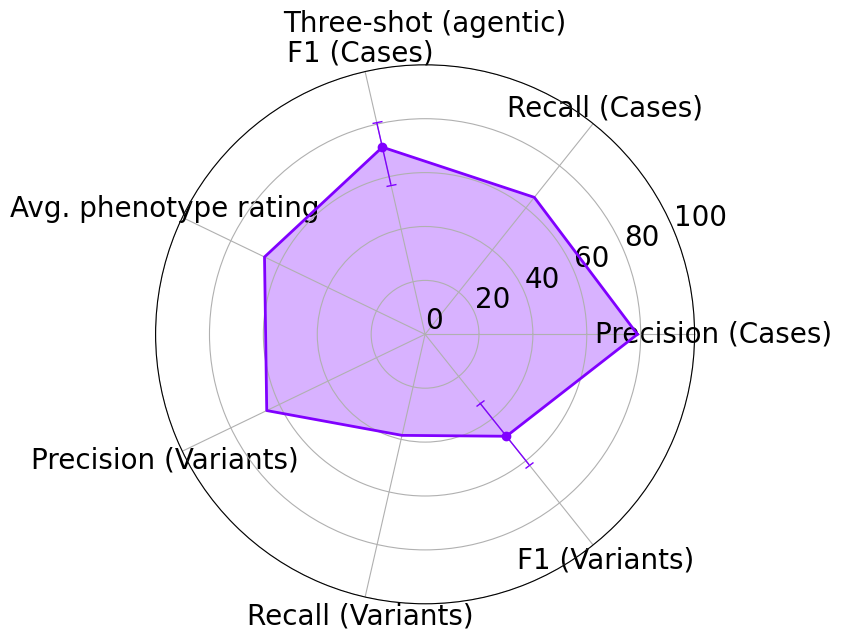

In [6]:
# ============================================================
#   Spider plot with confidence intervals
# ============================================================

def out_plt(out_dir, out_name, dpi=720, svg=True, png=True):
    '''
    Description:
        Write out plot as svg and png to outDir

    Example:
    `out_plt(out_dir, out_name) >> None`
    '''
    if not (os.path.exists(out_dir)):
        os.makedirs(ut_dir)

    if svg:
        name_svg = out_name + ".svg"
        file = os.path.join(out_dir, name_svg)
        plt.savefig(Path(file), format="svg", dpi=dpi, bbox_inches="tight")

    if png:
        name_png = out_name + ".png"
        file = os.path.join(out_dir, name_png)
        plt.savefig(Path(file), format="png", dpi=dpi, bbox_inches="tight")

    return None

def build_colour_map(n: int, map: colors.ListedColormap):
    """
    Description:
        Return list of colour strings of length `n` from `map`
    
    Returns:
        colours (list[str])

    Example
        `build_color_map(4, cm.magma)`
    """
    quartiles = np.linspace(0, 1, n, endpoint=False)
    colours = [map(q) for q in quartiles]
    colours = [colors.to_hex(c) for c in colours]
    return colours

def spider_pretty_f1_ci(
    f1_ci_data: dict,
    phenotype_rating: float,
    style="default",
    dims=(10, 7),
    title_size=20,
    label_size=20,
    alpha=0.3,
    linewidth=2,
    write=True,
    out_dir="./",
    out_name_suffix="_performMets_CI"
):
    cases_df = f1_ci_data["Cases"]
    var_df = f1_ci_data["Variants"]

    models = cases_df["Model"].to_list()
    colours = build_colour_map(len(models), cm.rainbow)

    for i in range(len(models)):
        tp_c, fp_c, fn_c, cnc_l, cnc_u = (
            cases_df["TP"][i],
            cases_df["FP"][i],
            cases_df["FN"][i],
            cases_df["CI_lower"][i],
            cases_df["CI_upper"][i]
        )
        tp_v, fp_v, fn_v, cnv_l, cnv_u = (
            var_df["TP"][i],
            var_df["FP"][i],
            var_df["FN"][i],
            var_df["CI_lower"][i],
            var_df["CI_upper"][i]
        )
        f1_c = cases_df["F1"][i]
        f1_v = var_df["F1"][i]

        scores = np.array([
            compute_precision(tp_c, fp_c),
            compute_recall(tp_c, fn_c),
            f1_c,
            phenotype_rating / 100,
            compute_precision(tp_v, fp_v),
            compute_recall(tp_v, fn_v),
            f1_v,
        ]) * 100

        fig, ax = plt.subplots(figsize=dims, subplot_kw={"projection": "polar"})
        plt.style.use(style)

        ax.set_ylim(0, 100)
        ax.set_yticks([0, 20, 40, 60, 80, 100])
        ax.set_yticklabels(
            ["0", "20", "40", "60", "80", "100"],
            fontsize=label_size
        )

        angles = np.linspace(0, 2 * np.pi, len(scores), endpoint=False).tolist()
        plt.title(models[i], fontsize=title_size, pad=int(1.2 * title_size))
        angles.append(angles[0])
        scores = np.append(scores, scores[0])

        ax.fill(angles, scores, color=colours[i], alpha=alpha)
        ax.plot(angles, scores, color=colours[i], linewidth=linewidth)

        f1_indices = [2, 6]
        f1_vals = np.array([f1_c, f1_v]) * 100
        f1_lows = np.array([cnc_l, cnv_l]) * 100
        f1_highs = np.array([cnc_u, cnv_u]) * 100
        f1_angles = np.array(angles[:-1])[f1_indices]

        yerr = np.vstack([
            f1_vals - f1_lows,
            f1_highs - f1_vals
        ])
        ax.errorbar(
            f1_angles,
            f1_vals,
            yerr=yerr,
            fmt="o",
            color=colours[i],
            capsize=4,
            linewidth=1
        )

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(
            [
                "Precision (Cases)",
                "Recall (Cases)",
                "F1 (Cases)",
                "Avg. phenotype rating",
                "Precision (Variants)",
                "Recall (Variants)",
                "F1 (Variants)"
            ],
            fontsize=label_size
        )

        if write:
            safe_name = re.sub(r"[^\w\s]", "", models[i])
            safe_name = re.sub(r"\s+", "_", safe_name)

            out_plt(
                out_dir=out_dir,
                out_name=f"{safe_name}{out_name_suffix}",
                dpi=720,
                svg=True,
                png=True
            )

        plt.show()

spider_pretty_f1_ci(
    f1_ci_data=f1_ci_data,
    phenotype_rating=phenotype_rating,
    out_dir=OUT_DIR
)